# 09 — UV Abundances: C/O and N/O from Rest-Frame UV Lines

**Purpose:** Derive C/O and UV-based N/O from UV semi-forbidden and
resonance lines in a dust-corrected composite spectrum.  Demonstrates
the new UV abundance support in `jwspecabund`.

### Lines used

| Ion | Lines | Abundance |
|-----|-------|-----------|
| C2+ | CIII] 1907 + 1909 | C++/H+ |
| C3+ | CIV 1548 + 1551 | C+++/H+ |
| N+ | [NII] 6585 | N+/H+ |
| N2+ | NIII] 1749 + 1752 | N++/H+ |
| N3+ | NIV] 1483 + 1486 | N+++/H+ |
| N4+ | NV 1239 + 1243 | N4+/H+ (manual emissivity) |
| O+ | [OII] 3726 + 3729 | O+/H+ |
| O2+ | [OIII] 4959 + 5007 | O++/H+ |

### Methodology

1. Fit UV + optical lines on the rest-frame stacked spectrum
2. Dust correction from multi-line Balmer decrement (Ha, Hgamma, Hdelta vs Hbeta)
3. Electron temperature from [OIII] 4363/(4959+5007)
4. Electron density from CIII] 1907/1909
5. Ionic abundances via PyNEB (+ manual NV emissivity)
6. C/O = (C2+ + C3+) / O2+ (Jones+2023)
7. N/O from three tracers (Berg+2025): N+/O+, direct sum, N2+/O2+
8. MC error propagation with pre-computed emissivity grids

**Data:** `stack_all_Muv19_21_DustCorrected.npz` — rest-frame composite
spectrum (z = 0, 1000–7500 Å, 129 galaxies).

**Date:** 2026-02-23

In [1]:
import jwspecfit
from jwspecfit.lines import REST_LINES_A
from jwspecfit.resolution import R_from_pixels
from jwspecabund.dust import salim_attenuation, compute_Av_from_balmer
from jwspecabund.forward import hbeta_emissivity_aller84, _nv_emissivity
import matplotlib.pyplot as plt
import numpy as np
import pyneb as pn

print(f"jwspecfit  v{jwspecfit.__version__}")
print(f"pyneb     v{pn.__version__}")

jwspecfit  v1.0.0
pyneb     v1.1.28


## 1. Load the stacked spectrum

In [2]:
spec = jwspecfit.read_npz("../../data/stack_all_Muv19_21.npz", z=0.0)

# Estimate R from pixel spacing
R_func = R_from_pixels(spec.wave_um)

v = spec.mask_valid()
print(f"Pixels:     {spec.n_pix} ({v.sum()} valid)")
print(f"Wave range: {spec.wave_um[v].min()*1e4:.0f} – {spec.wave_um[v].max()*1e4:.0f} Å")
print(f"R at 1500 Å: {R_func(0.15):.0f}")
print(f"R at 5000 Å: {R_func(0.50):.0f}")

Pixels:     13000 (12976 valid)
Wave range: 1012 – 7500 Å
R at 1500 Å: 1500
R at 5000 Å: 5000


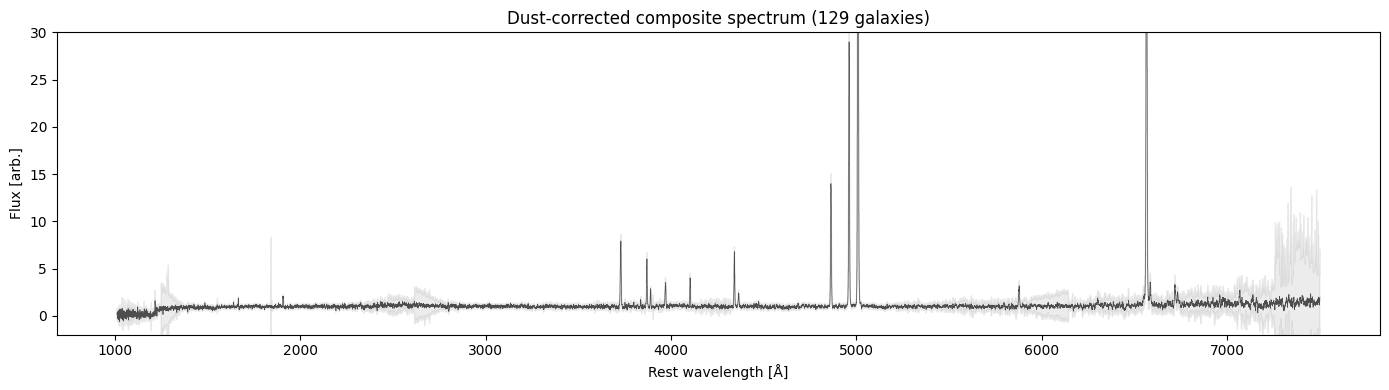

In [3]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.step(spec.wave_um[v] * 1e4, spec.flux_ujy[v], where="mid", lw=0.5, color="0.3")
ax.fill_between(
    spec.wave_um[v] * 1e4,
    (spec.flux_ujy - spec.err_ujy)[v],
    (spec.flux_ujy + spec.err_ujy)[v],
    step="mid", alpha=0.15, color="0.5",
)
ax.set_xlabel(r"Rest wavelength [Å]")
ax.set_ylabel(r"Flux [arb.]")
ax.set_title("Dust-corrected composite spectrum (129 galaxies)")
ax.set_ylim(-2, 30)
plt.tight_layout()

## 2. Fit UV lines (~1200–2000 Å)

In [4]:
import jwspecmcmc

uv_lines = [
    "NV_1", "NV_2",
    "NIV_1483", "NIV_1486",
    "CIV_1", "CIV_2",
    "HEII_1640",
    "OIII_1661", "OIII_1666",
    "NIII_1749", "NIII_1752",
    "SiIII_1", "SiIII_2",
    "CIII]_1907", "CIII]",
]

# Rest-frame spectrum at z=0, so observed = rest
result_uv = jwspecmcmc.fit_lines(
    spec, z=0.0,
    lines=uv_lines,
    wave_range_A=(1200, 2000),
    moving_average=100, 
    mode="off"
)

print(f"Lines fitted: {len(result_uv.lines)}")
print()
print(f"{'Line':<18s} {'Flux':>12s} {'Err':>12s} {'SNR':>8s}")
print("-" * 52)
for name, lr in result_uv.lines.items():
    print(f"{name:<18s} {lr.flux:12.3e} {lr.flux_err:12.3e} {lr.snr:8.1f}")

Resolving power: R ≈ 1600 (range 1200–2000)
Resolving power: R ≈ 1600 (range 1200–2000)


100%|██████████| 2000/2000 [01:18<00:00, 25.59it/s]
The chain is shorter than 50 times the integrated autocorrelation time for 45 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 40;
tau: [230.04055909 188.31288877 189.21656206 181.2123771  206.43056411
 175.70920001 181.78385691 178.88597663 183.02921977 192.89760903
 207.17439964 193.31257581 203.31955337 172.89460674 181.95076619
 240.04936664 234.71402836 229.52897946 222.35126871 229.87616506
 229.20215574 208.27247867 226.21431619 218.65610138 211.56303854
 220.77854676 214.91594747 214.37405713 215.21874558 212.8224655
 219.84073998 218.5654805  226.95834973 219.4471005  213.6026302
 216.54986764 210.40182205 222.16688902 220.77405734 219.35219642
 217.55775531 211.03117942 215.66267306 221.99944353 219.36031465]


Lines fitted: 15

Line                       Flux          Err      SNR
----------------------------------------------------


TypeError: unsupported format string passed to tuple.__format__

In [5]:
fig_interactive = jwspecfit.plot_fit_interactive(result_uv, wave_unit="A")
fig_interactive.show()

## 3. Fit optical lines (~4800–6800 Å)

In [8]:
optical_lines = [
    "HGAMMA", "OIII_4363", "OIII_4959", "OIII_5007",
    "HBETA", "Ha", "NII_6585", "SII_6718", "SII_6732",
]

result_opt = jwspecfit.fit_lines(
    spec, z=0.0,
    lines=optical_lines,
    wave_range_A=(4300, 6800),
    moving_average=100, n_boot=1000,mode="off"
)

print(f"Lines fitted: {len(result_opt.lines)}")
print(f"chi2/dof:     {result_opt.chi2:.2f}")
print()
print(f"{'Line':<18s} {'Flux':>12s} {'Err':>12s} {'SNR':>8s}")
print("-" * 52)
for name, lr in result_opt.lines.items():
    print(f"{name:<18s} {lr.flux:12.3e} {lr.flux_err:12.3e} {lr.snr:8.1f}")

Resolving power: R ≈ 5550 (range 4300–6800)


Bootstrap: 100%|██████████| 1000/1000 [00:34<00:00, 29.29iter/s]

Lines fitted: 9
chi2/dof:     0.27

Line                       Flux          Err      SNR
----------------------------------------------------
HGAMMA                4.084e-17    1.208e-18     33.8
OIII_4363             1.151e-17    7.999e-19     14.4
OIII_4959             1.906e-16    4.154e-18     45.9
OIII_5007             5.678e-16    1.160e-17     48.9
HBETA                 9.180e-17    1.883e-18     48.7
Ha                    2.410e-16    6.694e-18     36.0
NII_6585              7.013e-18    1.281e-18      5.5
SII_6718              6.976e-18    1.144e-18      6.1
SII_6732              3.489e-18    8.847e-19      3.9


In [9]:
fig_interactive = jwspecfit.plot_fit_interactive(result_opt, wave_unit="A")
fig_interactive.show()

## 3b. Fit [OII] + blue Balmer series (3600–4200 Å)

Fit the [OII] merged doublet for O+/H+, plus Hdelta for the
multi-line Balmer decrement.  Hepsilon (3970 Å) is also fitted here
but excluded from the dust determination — see §4.  H8 (3890 Å) is
skipped because it is blended with He I 3889.

In [8]:
blue_lines = ["OII_doublet", "HEPSILON", "HDELTA"]

result_blue = jwspecfit.fit_lines(
    spec, z=0.0, R=R_func,
    lines=blue_lines,
    wave_range_A=(3600, 4200),
    moving_average=100, n_boot=1000,
)

print(f"Lines fitted: {len(result_blue.lines)}")
print(f"chi2/dof:     {result_blue.chi2:.2f}")
print()
print(f"{'Line':<18s} {'Flux':>12s} {'Err':>12s} {'SNR':>8s}")
print("-" * 52)
for name, lr in result_blue.lines.items():
    print(f"{name:<18s} {lr.flux:12.3e} {lr.flux_err:12.3e} {lr.snr:8.1f}")

Resolving power: R ≈ 4250 (range 1000–7500)


Bootstrap (narrow): 100%|██████████| 1000/1000 [00:16<00:00, 61.14iter/s]

Lines fitted: 3
chi2/dof:     1.11

Line                       Flux          Err      SNR
----------------------------------------------------
OII_doublet           8.509e-17    2.628e-18     32.4
HEPSILON              2.526e-17    1.621e-18     15.6
HDELTA                2.135e-17    1.387e-18     15.4


In [9]:
fig_interactive = jwspecfit.plot_fit_interactive(result_blue, wave_unit="A")
fig_interactive.show()

## 4. Dust correction from multi-line Balmer decrement

Fit A_V simultaneously from all detected Balmer ratios relative to Hbeta
(Ha, Hgamma, Hdelta).  Case B intrinsic ratios are computed from PyNEB
at Te = 10,000 K, ne = 100 cm⁻³ (the ratios vary by < 2% over the
8,000–20,000 K range).

**Excluded lines:**
- **H8** (3890 Å): blended with He I 3889 (0.4 Å separation).
- **Hepsilon** (3970 Å): contaminated by [Ne III] 3968 — the observed
  Hε/Hβ ratio is ~1.7× the Case B value, indicating significant
  [Ne III] flux absorbed into the Hε Gaussian.

In [10]:
from scipy.optimize import minimize_scalar

def get_flux(result, name):
    lr = result.lines.get(name)
    if lr is None:
        return np.nan, np.nan
    return lr.flux, lr.flux_err

# Case B intrinsic ratios from PyNEB (Te=10000 K, ne=100 cm^-3)
H1_ref = pn.RecAtom('H', 1)
j_Hb_ref = H1_ref.getEmissivity(1e4, 100, wave=4861)
balmer_info = {
    # name: (result_obj, rest_wave_A, PyNEB_wave)
    "Ha":       (result_opt,  REST_LINES_A["Ha"],       6563),
    "HGAMMA":   (result_opt,  REST_LINES_A["HGAMMA"],   4340),
    "HDELTA":   (result_blue, REST_LINES_A["HDELTA"],    4102),
    # Hepsilon excluded: contaminated by [NeIII] 3968
    # (R_obs/R_int ~ 1.7, [NeIII] flux inflates the Gaussian)
}

print(f"{'Line':<12s} {'Flux':>12s} {'Err':>12s} {'SNR':>6s} {'R_obs':>8s} {'R_int':>8s}")
print("-" * 62)

lines_for_fit = []
for name, (res, rwave, pyneb_w) in balmer_info.items():
    f, e = get_flux(res, name)
    f_Hb, e_Hb = get_flux(result_opt, "HBETA")
    if not (np.isfinite(f) and f > 0 and np.isfinite(e) and e > 0):
        continue
    snr = f / e
    R_obs = f / f_Hb
    R_int = H1_ref.getEmissivity(1e4, 100, wave=pyneb_w) / j_Hb_ref
    sigma_R = R_obs * np.sqrt((e / f) ** 2 + (e_Hb / f_Hb) ** 2)
    k_line = salim_attenuation(np.array([rwave]), 1.0)[0]
    k_Hb = salim_attenuation(np.array([REST_LINES_A["HBETA"]]), 1.0)[0]
    lines_for_fit.append((name, R_obs, R_int, sigma_R, k_line, k_Hb))
    print(f"{name:<12s} {f:12.3e} {e:12.3e} {snr:6.1f} {R_obs:8.4f} {R_int:8.4f}")

# Chi-squared fit for A_V
def chi2_Av(Av):
    c2 = 0.0
    for name, R_obs, R_int, sigma_R, k_line, k_Hb in lines_for_fit:
        R_model = R_int * 10.0 ** (-0.4 * Av * (k_line - k_Hb))
        c2 += ((R_obs - R_model) / sigma_R) ** 2
    return c2

res = minimize_scalar(chi2_Av, bounds=(-1.0, 5.0), method="bounded")
Av = max(res.x, 0.0)

# Error from Delta-chi2 = 1
chi2_min = res.fun
def find_Av_err(direction):
    from scipy.optimize import brentq
    target = chi2_min + 1.0
    try:
        if direction > 0:
            return brentq(lambda a: chi2_Av(a) - target, Av, Av + 5.0) - Av
        else:
            return Av - brentq(lambda a: chi2_Av(a) - target, max(Av - 5.0, -1.0), Av)
    except ValueError:
        return np.nan

Av_err_hi = find_Av_err(+1)
Av_err_lo = find_Av_err(-1)
Av_err = 0.5 * (Av_err_hi + Av_err_lo)

print(f"\nA_V = {Av:.3f}  (+{Av_err_hi:.3f} / -{Av_err_lo:.3f})")
print(f"chi2/dof = {chi2_min:.2f} / {len(lines_for_fit) - 1}")

# Report per-line A_V for comparison
print(f"\nPer-line A_V estimates:")
for name, R_obs, R_int, sigma_R, k_line, k_Hb in lines_for_fit:
    dk = k_Hb - k_line
    if abs(dk) > 1e-10:
        Av_i = 2.5 * np.log10(R_obs / R_int) / dk
        print(f"  {name:<12s}  A_V = {Av_i:+.3f}")

# Dust correction helper
def dust_correct(flux, flux_err, rest_wave_A, Av):
    if Av <= 0 or not np.isfinite(Av):
        return flux, flux_err
    A_lam = salim_attenuation(np.array([rest_wave_A]), Av)[0]
    factor = 10.0 ** (0.4 * A_lam)
    return flux * factor, flux_err * factor

Line                 Flux          Err    SNR    R_obs    R_int
--------------------------------------------------------------
Ha              2.410e-16    6.694e-18   36.0   2.6254   2.8632
HGAMMA          4.084e-17    1.208e-18   33.8   0.4449   0.4683
HDELTA          2.135e-17    1.387e-18   15.4   0.2326   0.2589

A_V = 0.000  (+nan / -nan)
chi2/dof = 10.44 / 2

Per-line A_V estimates:
  Ha            A_V = -0.174
  HGAMMA        A_V = +0.222
  HDELTA        A_V = +0.302


## 5. Electron temperature and density

In [11]:
O3 = pn.Atom('O', 3)
C3 = pn.Atom('C', 3)
N3_atom = pn.Atom('N', 3)
N4_atom = pn.Atom('N', 4)
C4 = pn.Atom('C', 4)
H1 = pn.RecAtom('H', 1)

# Dust-corrected optical fluxes
f_4363, e_4363 = get_flux(result_opt, "OIII_4363")
f_4959, e_4959 = get_flux(result_opt, "OIII_4959")
f_5007, e_5007 = get_flux(result_opt, "OIII_5007")

f_4363_c, _ = dust_correct(f_4363, e_4363, 4364.44, Av)
f_4959_c, _ = dust_correct(f_4959, e_4959, 4961.68, Av)
f_5007_c, _ = dust_correct(f_5007, e_5007, 5009.64, Av)

ratio_oiii = f_4363_c / (f_4959_c + f_5007_c)
print(f"[OIII] 4363 SNR = {f_4363/e_4363:.1f}")
print(f"[OIII] 4363/(4959+5007) = {ratio_oiii:.4f}")

# Te from [OIII]
ne_init = 1000.0  # initial guess
Te_high = O3.getTemDen(
    ratio_oiii, den=ne_init,
    to_eval="L(4363) / (L(4959) + L(5007))",
    start_x=3.5, end_x=5.0, log=True,
)
print(f"Te(O2+) = {Te_high:.0f} K")

# ne from CIII] 1907/1909
f_c3_07, e_c3_07 = get_flux(result_uv, "CIII]_1907")
f_c3_09, e_c3_09 = get_flux(result_uv, "CIII]")

ne = ne_init
if f_c3_07 > 0 and f_c3_09 > 0:
    f_c3_07_c, _ = dust_correct(f_c3_07, e_c3_07, 1906.68, Av)
    f_c3_09_c, _ = dust_correct(f_c3_09, e_c3_09, 1908.73, Av)
    ratio_ciii = f_c3_07_c / f_c3_09_c
    ne_ciii = C3.getTemDen(ratio_ciii, tem=Te_high, wave1=1907, wave2=1909)
    if np.isfinite(ne_ciii) and ne_ciii > 0:
        ne = float(ne_ciii)
        print(f"CIII] 1907/1909 = {ratio_ciii:.3f}  ->  ne = {ne:.0f} cm^-3")
    else:
        print(f"CIII] ratio = {ratio_ciii:.3f} (outside physical range, using ne={ne:.0f})")
else:
    print(f"CIII] not detected, using ne = {ne:.0f} cm^-3")

# Recompute Te with refined ne
Te_high = O3.getTemDen(
    ratio_oiii, den=ne,
    to_eval="L(4363) / (L(4959) + L(5007))",
    start_x=3.5, end_x=5.0, log=True,
)
print(f"\nFinal Te(O2+) = {Te_high:.0f} K  (ne = {ne:.0f} cm^-3)")

[OIII] 4363 SNR = 14.4
[OIII] 4363/(4959+5007) = 0.0152
Te(O2+) = 15242 K
CIII] 1907/1909 = 0.762  ->  ne = 40856 cm^-3

Final Te(O2+) = 14314 K  (ne = 40856 cm^-3)


## 6. Ionic abundances

All UV ionic abundances use Te(O2+) — appropriate for the high-ionisation zone.

In [12]:
def get_j_Hb(Te, ne):
    """Hbeta emissivity with Aller 1984 fallback for Te > 30,000 K."""
    try:
        val = H1.getEmissivity(Te, ne, wave=4861)
        if np.isfinite(val):
            return val
    except Exception:
        pass
    return hbeta_emissivity_aller84(Te)


f_Hb_c, e_Hb_c = dust_correct(f_Hb, e_Hb, 4864.04, Av)
j_Hb = get_j_Hb(Te_high, ne)

print(f"{'Ion':<12s} {'Lines':<20s} {'Flux':>12s} {'X/H+':>12s} {'12+log':>10s}")
print("-" * 68)

# O2+/H+ from [OIII] 5007
j_5007 = O3.getEmissivity(Te_high, ne, wave=5007)
Opp = (f_5007_c / f_Hb_c) * (j_Hb / j_5007)
print(f"{'O2+':<12s} {'[OIII] 5007':<20s} {f_5007_c:12.3e} {Opp:12.3e} {12+np.log10(Opp):10.3f}")

# C2+/H+ from CIII] 1907+1909
f_ciii = 0.0
for name in ["CIII]_1907", "CIII]"]:
    f, e = get_flux(result_uv, name)
    if np.isfinite(f) and f > 0:
        f_ciii += f
Cpp = np.nan
if f_ciii > 0:
    f_ciii_c, _ = dust_correct(f_ciii, 0, 1908.0, Av)
    eps = C3.getEmissivity(Te_high, ne, wave=1907) + C3.getEmissivity(Te_high, ne, wave=1909)
    Cpp = (f_ciii_c / f_Hb_c) * (j_Hb / eps)
    print(f"{'C2+':<12s} {'CIII] 1907+1909':<20s} {f_ciii_c:12.3e} {Cpp:12.3e} {12+np.log10(Cpp):10.3f}")

# C3+/H+ from CIV 1548+1551
f_civ = 0.0
for name in ["CIV_1", "CIV_2"]:
    f, e = get_flux(result_uv, name)
    if np.isfinite(f) and f > 0:
        f_civ += f
Cppp = np.nan
if f_civ > 0:
    f_civ_c, _ = dust_correct(f_civ, 0, 1549.0, Av)
    eps_civ = C4.getEmissivity(Te_high, ne, wave=1548) + C4.getEmissivity(Te_high, ne, wave=1551)
    Cppp = (f_civ_c / f_Hb_c) * (j_Hb / eps_civ)
    print(f"{'C3+':<12s} {'CIV 1548+1551':<20s} {f_civ_c:12.3e} {Cppp:12.3e} {12+np.log10(Cppp):10.3f}")

# N2+/H+ from NIII] 1749+1752
f_niii = 0.0
for name in ["NIII_1749", "NIII_1752"]:
    f, e = get_flux(result_uv, name)
    if np.isfinite(f) and f > 0:
        f_niii += f
Npp = np.nan
if f_niii > 0:
    f_niii_c, _ = dust_correct(f_niii, 0, 1750.0, Av)
    eps_niii = N3_atom.getEmissivity(Te_high, ne, wave=1749) + N3_atom.getEmissivity(Te_high, ne, wave=1752)
    Npp = (f_niii_c / f_Hb_c) * (j_Hb / eps_niii)
    print(f"{'N2+':<12s} {'NIII] 1749+1752':<20s} {f_niii_c:12.3e} {Npp:12.3e} {12+np.log10(Npp):10.3f}")

# N3+/H+ from NIV] 1483+1486
f_niv = 0.0
for name in ["NIV_1483", "NIV_1486"]:
    f, e = get_flux(result_uv, name)
    if np.isfinite(f) and f > 0:
        f_niv += f
Nppp = np.nan
if f_niv > 0:
    f_niv_c, _ = dust_correct(f_niv, 0, 1486.5, Av)
    eps_niv = N4_atom.getEmissivity(Te_high, ne, wave=1487) + N4_atom.getEmissivity(Te_high, ne, wave=1483)
    Nppp = (f_niv_c / f_Hb_c) * (j_Hb / eps_niv)
    print(f"{'N3+':<12s} {'NIV] 1483+1486':<20s} {f_niv_c:12.3e} {Nppp:12.3e} {12+np.log10(Nppp):10.3f}")

# N4+/H+ from NV 1239+1243 (manual emissivity)
f_nv = 0.0
for name in ["NV_1", "NV_2"]:
    f, e = get_flux(result_uv, name)
    if np.isfinite(f) and f > 0:
        f_nv += f
Npppp = np.nan
if f_nv > 0:
    f_nv_c, _ = dust_correct(f_nv, 0, 1240.0, Av)
    eps_nv = _nv_emissivity(Te_high, ne, 1239) + _nv_emissivity(Te_high, ne, 1243)
    if eps_nv > 0:
        Npppp = (f_nv_c / f_Hb_c) * (j_Hb / eps_nv)
        print(f"{'N4+':<12s} {'NV 1239+1243':<20s} {f_nv_c:12.3e} {Npppp:12.3e} {12+np.log10(Npppp):10.3f}")

Ion          Lines                        Flux         X/H+     12+log
--------------------------------------------------------------------
O2+          [OIII] 5007             5.678e-16    7.684e-05      7.886
C2+          CIII] 1907+1909         3.666e-17    9.334e-06      6.970
C3+          CIV 1548+1551           1.360e-17    2.178e-06      6.338
N2+          NIII] 1749+1752         6.426e-18    1.792e-05      7.253
N3+          NIV] 1483+1486          1.797e-17    1.604e-05      7.205
N4+          NV 1239+1243            2.180e-17    7.339e-08      4.866


## 7. C/O ratio

C2+ and C3+ both coexist with O2+ in the high-ionisation zone
(ionisation potentials 24–65 eV vs 35–55 eV), so C/O = (C2+ + C3+) / O2+
is a physically grounded ratio (Jones+2023).

N/O is deferred to §10 where we use the direct-sum method (Berg+2025),
which requires O+ and N+ from the optical lines fitted in §3b.

In [13]:
# C/O = (C2+ + C3+) / O2+
C_total = sum(x for x in [Cpp, Cppp] if np.isfinite(x))
if C_total > 0 and Opp > 0:
    CO = C_total / Opp
    print(f"C/O  = (C2+ + C3+) / O2+ = {CO:.4f}")
    print(f"log(C/O) = {np.log10(CO):.3f}")
    C_ions = {"C2+": Cpp, "C3+": Cppp}
    for ion, val in C_ions.items():
        if np.isfinite(val):
            print(f"  {ion}/C = {val/C_total:.1%}")
else:
    print("C/O not available")

C/O  = (C2+ + C3+) / O2+ = 0.1498
log(C/O) = -0.824
  C2+/C = 81.1%
  C3+/C = 18.9%


## 8. Monte Carlo error propagation

Pre-compute emissivity grids as a function of Te, then use vectorised
`np.interp` — same approach as notebook 08.

In [14]:
n_mc = 10000
rng = np.random.default_rng(42)

# Pre-compute emissivity grids
print("Pre-computing emissivity grids ...")
Te_g = np.linspace(5000, 80000, 500)

# [OIII] auroral/nebular ratio R(Te)
R_g = np.array([
    O3.getEmissivity(T, ne, wave=4363) /
    (O3.getEmissivity(T, ne, wave=4959) + O3.getEmissivity(T, ne, wave=5007))
    for T in Te_g
])

# O2+
j_5007_g = np.array([O3.getEmissivity(T, ne, wave=5007) for T in Te_g])
j_Hb_g = np.array([get_j_Hb(T, ne) for T in Te_g])

# C2+ (CIII])
j_ciii_g = np.array([
    C3.getEmissivity(T, ne, wave=1907) + C3.getEmissivity(T, ne, wave=1909)
    for T in Te_g
])

# C3+ (CIV)
j_civ_g = np.array([
    C4.getEmissivity(T, ne, wave=1548) + C4.getEmissivity(T, ne, wave=1551)
    for T in Te_g
])

# N2+ (NIII])
j_niii_g = np.array([
    N3_atom.getEmissivity(T, ne, wave=1749) + N3_atom.getEmissivity(T, ne, wave=1752)
    for T in Te_g
])

# N3+ (NIV]) — must sum BOTH doublet components
j_niv_g = np.array([
    N4_atom.getEmissivity(T, ne, wave=1487) + N4_atom.getEmissivity(T, ne, wave=1483)
    for T in Te_g
])

print("Done.")

Pre-computing emissivity grids ...
Done.


In [15]:
# Collect all fluxes and errors
flux_names = {
    "OIII_4363": (result_opt, 4364.44),
    "OIII_4959": (result_opt, 4961.68),
    "OIII_5007": (result_opt, 5009.64),
    "HBETA":     (result_opt, REST_LINES_A["HBETA"]),
    "Ha":        (result_opt, REST_LINES_A["Ha"]),
    "HGAMMA":    (result_opt, REST_LINES_A["HGAMMA"]),
    "HDELTA":    (result_blue, REST_LINES_A["HDELTA"]),
    "CIII]_1907": (result_uv, 1906.68),
    "CIII]":      (result_uv, 1908.73),
    "CIV_1":      (result_uv, 1548.19),
    "CIV_2":      (result_uv, 1550.77),
    "NIII_1749":  (result_uv, 1748.65),
    "NIII_1752":  (result_uv, 1752.16),
    "NIV_1483":   (result_uv, 1483.32),
    "NIV_1486":   (result_uv, 1486.50),
}

# Draw MC samples
mc_fluxes = {}
for name, (res, rwave) in flux_names.items():
    f, e = get_flux(res, name)
    if np.isfinite(f) and np.isfinite(e) and e > 0:
        mc_fluxes[name] = rng.normal(f, e, size=n_mc)
    else:
        mc_fluxes[name] = np.full(n_mc, np.nan)

# k(lambda)/A_V for each rest wavelength
kv = {}
for name, (_, rwave) in flux_names.items():
    kv[name] = salim_attenuation(np.array([rwave]), 1.0)[0]

# Multi-line Balmer A_V per MC sample
# Pre-compute intrinsic ratios and differential k-values
balmer_mc_info = []
for name, R_obs, R_int, sigma_R, k_line, k_Hb in lines_for_fit:
    if name in mc_fluxes:
        balmer_mc_info.append((name, R_int, k_line - k_Hb))

Av_s = np.zeros(n_mc)
for i in range(n_mc):
    Hb_i = mc_fluxes["HBETA"][i]
    if Hb_i <= 0 or not np.isfinite(Hb_i):
        Av_s[i] = 0.0
        continue
    # Weighted average of per-line A_V estimates
    w_sum, wAv_sum = 0.0, 0.0
    for name, R_int, dk in balmer_mc_info:
        fi = mc_fluxes[name][i]
        if fi <= 0 or not np.isfinite(fi) or abs(dk) < 1e-10:
            continue
        R_i = fi / Hb_i
        if R_i <= 0:
            continue
        Av_i = -2.5 * np.log10(R_i / R_int) / (0.4 * dk)
        # Weight by dk^2 (lines with larger wavelength lever arm are more constraining)
        w = dk ** 2
        w_sum += w
        wAv_sum += w * Av_i
    Av_s[i] = max(wAv_sum / w_sum, 0.0) if w_sum > 0 else 0.0

def dc(name):
    return mc_fluxes[name] * 10.0 ** (0.4 * kv[name] * Av_s)

# Dust-corrected MC fluxes
c_Hb   = dc("HBETA")
c_4363 = dc("OIII_4363")
c_4959 = dc("OIII_4959")
c_5007 = dc("OIII_5007")
c_ciii = dc("CIII]_1907") + dc("CIII]")
c_civ  = dc("CIV_1") + dc("CIV_2")
c_niii = dc("NIII_1749") + dc("NIII_1752")
c_niv  = dc("NIV_1483") + dc("NIV_1486")

# Te from [OIII] ratio
with np.errstate(invalid="ignore", divide="ignore"):
    ratio_s = c_4363 / (c_4959 + c_5007)
Te_s = np.interp(ratio_s, R_g, Te_g)
Te_s[~np.isfinite(ratio_s) | (ratio_s < R_g[0]) | (ratio_s > R_g[-1])] = np.nan

# Interpolate emissivities
bad = ~np.isfinite(Te_s)
def interp_g(grid):
    arr = np.interp(Te_s, Te_g, grid)
    arr[bad] = np.nan
    return arr

ej_5007 = interp_g(j_5007_g)
ej_Hb   = interp_g(j_Hb_g)
ej_ciii = interp_g(j_ciii_g)
ej_civ  = interp_g(j_civ_g)
ej_niii = interp_g(j_niii_g)
ej_niv  = interp_g(j_niv_g)

# Ionic abundances (vectorised)
with np.errstate(invalid="ignore", divide="ignore"):
    Opp_s   = (c_5007 / c_Hb) * (ej_Hb / ej_5007)
    Cpp_s   = np.where(c_ciii > 0, (c_ciii / c_Hb) * (ej_Hb / ej_ciii), np.nan)
    Cppp_s  = np.where(c_civ > 0, (c_civ / c_Hb) * (ej_Hb / ej_civ), np.nan)
    Npp_s   = np.where(c_niii > 0, (c_niii / c_Hb) * (ej_Hb / ej_niii), np.nan)
    Nppp_s  = np.where(c_niv > 0, (c_niv / c_Hb) * (ej_Hb / ej_niv), np.nan)

# C/O and O/H
def pos_or_zero(arr):
    return np.where(np.isfinite(arr) & (arr > 0), arr, 0.0)

C_s = pos_or_zero(Cpp_s) + pos_or_zero(Cppp_s)
O_s = pos_or_zero(Opp_s)

with np.errstate(invalid="ignore", divide="ignore"):
    OH_s = np.where(O_s > 0, 12 + np.log10(O_s), np.nan)
    CO_s = np.where((C_s > 0) & (O_s > 0), np.log10(C_s / O_s), np.nan)

# Report
good = np.isfinite(Te_s) & np.isfinite(OH_s)
print(f"Valid MC samples: {good.sum()}/{n_mc} ({good.sum()/n_mc*100:.0f}%)\n")

def report(arr, label, fmt=".3f"):
    v = arr[np.isfinite(arr)]
    if len(v) == 0:
        print(f"  {label}: no valid samples")
        return
    lo, med, hi = np.percentile(v, [16, 50, 84])
    print(f"  {label:20s} = {med:{fmt}}   +{hi-med:{fmt}} / -{med-lo:{fmt}}")

report(Av_s, "A_V")
report(Te_s, "Te [K]", fmt=".0f")
report(OH_s, "12+log(O/H)")
report(CO_s, "log(C/O)")

Valid MC samples: 10000/10000 (100%)

  A_V                  = 0.038   +0.167 / -0.038
  Te [K]               = 14453   +520 / -485
  12+log(O/H)          = 7.873   +0.044 / -0.044
  log(C/O)             = -0.754   +0.183 / -0.101


## 9. Summary plots

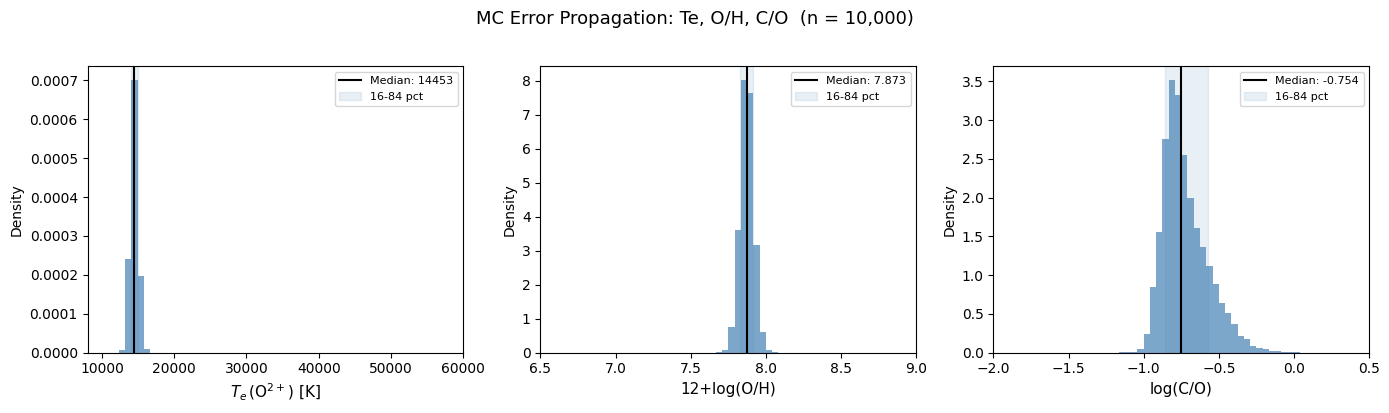

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

quantities = [
    (Te_s, r"$T_e\,(\mathrm{O}^{2+})$ [K]", ".0f", (8000, 60000)),
    (OH_s, r"12+log(O/H)", ".3f", (6.5, 9.0)),
    (CO_s, r"log(C/O)", ".3f", (-2.0, 0.5)),
]

for ax, (arr, label, fmt, (xlo, xhi)) in zip(axes, quantities):
    v = arr[np.isfinite(arr)]
    v = v[(v >= xlo) & (v <= xhi)]
    if len(v) == 0:
        ax.text(0.5, 0.5, "No valid samples", transform=ax.transAxes, ha="center")
        continue
    lo, med, hi = np.percentile(v, [16, 50, 84])

    ax.hist(v, bins=60, color="steelblue", alpha=0.7, density=True,
            range=(xlo, xhi))
    ax.axvline(med, color="k", lw=1.5,
               label=f"Median: {med:{fmt}}")
    ax.axvspan(lo, hi, alpha=0.12, color="steelblue", label="16-84 pct")

    ax.set_xlim(xlo, xhi)
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8, loc="upper right")

fig.suptitle(f"MC Error Propagation: Te, O/H, C/O  (n = {n_mc:,})", fontsize=13, y=1.02)
plt.tight_layout()

## 10. N/O from three independent tracers

Following Berg+2025 (arXiv:2511.13591), who measure N/O from four
methods on a z = 6.1 galaxy, we compare three approaches:

| # | Tracer | Lines | Method |
|---|--------|-------|--------|
| 1 | N+/O+ | [NII] 6585 / [OII] 3726+3729 | Low-ionisation proxy |
| 2 | Direct sum | (N+ + N2+ + N3+) / (O+ + O2+) | Multi-ion, model-free (Berg+25 eq. 5) |
| 3 | N2+/O2+ | NIII] 1749+1752 / [OIII] 5007 | UV single-zone proxy |

**Method 2** is the most complete: it sums all detected nitrogen
ions (N+, N2+, N3+) and divides by total detected oxygen (O+ + O2+),
avoiding the need for ICFs from photoionisation models.  The only
assumption is that N4+ and O3+ are negligible (N4+ is < 1% of total
N here).

Methods 1 and 3 are single-ion-pair ratios that bracket the true N/O:
N+/O+ underestimates because it misses N in higher stages, while
N2+/O2+ may over- or under-estimate depending on the ICF (Berg+25
find ICF(N2+/O2+) ~ 2.5 from Martinez+25 models).

In [17]:
from jwspecabund.icf import icf_nitrogen

# Te_low from DESI DR2 Te-Te relation
Te_low = 0.648 * Te_high + 3270.0
print(f"Te_high = {Te_high:.0f} K")
print(f"Te_low  = {Te_low:.0f} K  (DESI DR2)")
print(f"ne      = {ne:.0f} cm^-3\n")

# Initialise low-ionisation atoms
O2_atom = pn.Atom('O', 2)
N2_atom = pn.Atom('N', 2)

# O+/H+ from [OII] doublet at Te_low
f_oii, e_oii = get_flux(result_blue, "OII_doublet")
f_oii_c, _ = dust_correct(f_oii, e_oii, 3728.0, Av)

j_Hb_low = get_j_Hb(Te_low, ne)
j_oii = (O2_atom.getEmissivity(Te_low, ne, wave=3726)
         + O2_atom.getEmissivity(Te_low, ne, wave=3729))
Op = (f_oii_c / f_Hb_c) * (j_Hb_low / j_oii)

# N+/H+ from [NII] 6585 at Te_low
f_nii, e_nii = get_flux(result_opt, "NII_6585")
f_nii_c, _ = dust_correct(f_nii, e_nii, REST_LINES_A["NII_6585"], Av)
j_nii = N2_atom.getEmissivity(Te_low, ne, wave=6584)
Np = (f_nii_c / f_Hb_c) * (j_Hb_low / j_nii)

print(f"{'Ion':<8s} {'X/H+':>12s} {'12+log':>10s}")
print("-" * 32)
print(f"{'O+':<8s} {Op:12.3e} {12+np.log10(Op):10.3f}")
print(f"{'O2+':<8s} {Opp:12.3e} {12+np.log10(Opp):10.3f}")
print(f"{'N+':<8s} {Np:12.3e} {12+np.log10(Np):10.3f}")
if np.isfinite(Npp):
    print(f"{'N2+':<8s} {Npp:12.3e} {12+np.log10(Npp):10.3f}")
if np.isfinite(Nppp):
    print(f"{'N3+':<8s} {Nppp:12.3e} {12+np.log10(Nppp):10.3f}")

# --- Three N/O tracers ---
NO_1 = Np / Op                   # N+/O+ (optical)

# Direct sum: (N+ + N2+ + N3+) / (O+ + O2+)  — Berg+25 Method 4
N_sum = Np + sum(x for x in [Npp, Nppp] if np.isfinite(x))
O_sum = Op + Opp
NO_2 = N_sum / O_sum

NO_3 = Npp / Opp                 # N2+/O2+ (UV, matched IPs)

print(f"\n{'Tracer':<45s} {'N/O':>10s} {'log(N/O)':>10s}")
print("-" * 67)
print(f"{'1. N+/O+ (optical)':<45s} {NO_1:10.4f} {np.log10(NO_1):10.3f}")
print(f"{'2. Direct sum (N+ + N2+ + N3+)/(O+ + O2+)':<45s} {NO_2:10.4f} {np.log10(NO_2):10.3f}")
print(f"{'3. N2+/O2+ (UV, matched IPs)':<45s} {NO_3:10.4f} {np.log10(NO_3):10.3f}")

# Breakdown of contributions
print(f"\nDirect sum breakdown:")
print(f"  N+  = {Np/N_sum:.1%}   O+  = {Op/O_sum:.1%}")
n2_frac = Npp/N_sum if np.isfinite(Npp) else 0
n3_frac = Nppp/N_sum if np.isfinite(Nppp) else 0
print(f"  N2+ = {n2_frac:.1%}   O2+ = {Opp/O_sum:.1%}")
print(f"  N3+ = {n3_frac:.1%}")

Te_high = 14314 K
Te_low  = 12545 K  (DESI DR2)
ne      = 40856 cm^-3

Ion              X/H+     12+log
--------------------------------
O+          9.448e-05      7.975
O2+         7.684e-05      7.886
N+          1.301e-06      6.114
N2+         1.792e-05      7.253
N3+         1.604e-05      7.205

Tracer                                               N/O   log(N/O)
-------------------------------------------------------------------
1. N+/O+ (optical)                                0.0138     -1.861
2. Direct sum (N+ + N2+ + N3+)/(O+ + O2+)         0.2058     -0.686
3. N2+/O2+ (UV, matched IPs)                      0.2332     -0.632

Direct sum breakdown:
  N+  = 3.7%   O+  = 55.1%
  N2+ = 50.8%   O2+ = 44.9%
  N3+ = 45.5%


In [18]:
# Add [OII] and [NII] MC draws
extra_lines = {
    "OII_doublet": (result_blue, 3728.48),
    "NII_6585": (result_opt, REST_LINES_A["NII_6585"]),
}

for name, (res, rwave) in extra_lines.items():
    f, e = get_flux(res, name)
    if np.isfinite(f) and np.isfinite(e) and e > 0:
        mc_fluxes[name] = rng.normal(f, e, size=n_mc)
    else:
        mc_fluxes[name] = np.full(n_mc, np.nan)
    kv[name] = salim_attenuation(np.array([rwave]), 1.0)[0]

# Pre-compute emissivity grids for the low-ionisation zone
print("Pre-computing low-ionisation emissivity grids ...")
O2_atom = pn.Atom('O', 2)
N2_atom = pn.Atom('N', 2)

j_oii_g = np.array([
    O2_atom.getEmissivity(T, ne, wave=3726)
    + O2_atom.getEmissivity(T, ne, wave=3729)
    for T in Te_g
])
j_nii_g = np.array([
    N2_atom.getEmissivity(T, ne, wave=6584) for T in Te_g
])
j_Hb_any_g = np.array([get_j_Hb(T, ne) for T in Te_g])
print("Done.")

# Te_low per MC sample (DESI DR2 relation)
Te_low_s = 0.648 * Te_s + 3270.0

# Dust-corrected MC fluxes for [OII] and [NII]
c_oii_s = dc("OII_doublet")
c_nii_s = dc("NII_6585")

# Emissivities at Te_low (interpolate on the Te_g grid)
bad_low = ~np.isfinite(Te_low_s)
ej_oii   = np.interp(Te_low_s, Te_g, j_oii_g);   ej_oii[bad_low]   = np.nan
ej_nii   = np.interp(Te_low_s, Te_g, j_nii_g);   ej_nii[bad_low]   = np.nan
ej_Hb_lo = np.interp(Te_low_s, Te_g, j_Hb_any_g); ej_Hb_lo[bad_low] = np.nan

# O+/H+ and N+/H+ at Te_low
with np.errstate(invalid="ignore", divide="ignore"):
    Op_s = np.where(c_oii_s > 0, (c_oii_s / c_Hb) * (ej_Hb_lo / ej_oii), np.nan)
    Np_s = np.where(c_nii_s > 0, (c_nii_s / c_Hb) * (ej_Hb_lo / ej_nii), np.nan)

# --- Three N/O tracers (MC) ---
with np.errstate(invalid="ignore", divide="ignore"):
    # 1. N+/O+ (optical, low-ionisation proxy)
    NO_1_s = np.where(
        (Np_s > 0) & (Op_s > 0),
        np.log10(Np_s / Op_s), np.nan,
    )

    # 2. Direct sum: (N+ + N2+ + N3+) / (O+ + O2+)  — Berg+25 Method 4
    N_sum_s = pos_or_zero(Np_s) + pos_or_zero(Npp_s) + pos_or_zero(Nppp_s)
    O_sum_s = pos_or_zero(Op_s) + pos_or_zero(Opp_s)
    NO_2_s = np.where(
        (N_sum_s > 0) & (O_sum_s > 0),
        np.log10(N_sum_s / O_sum_s), np.nan,
    )

    # 3. N2+/O2+ (UV, matched ionisation potentials)
    NO_3_s = np.where(
        (Npp_s > 0) & (Opp_s > 0),
        np.log10(Npp_s / Opp_s), np.nan,
    )

# Report
def report_no(arr, label):
    v = arr[np.isfinite(arr)]
    if len(v) == 0:
        print(f"  {label:<45s}  no valid samples")
        return
    lo, med, hi = np.percentile(v, [16, 50, 84])
    print(f"  {label:<45s} {med:+.3f}  (+{hi-med:.3f} / -{med-lo:.3f})  [{len(v):,} samples]")

print("log(N/O) from three tracers:\n")
report_no(NO_1_s, "1. N+/O+ (optical)")
report_no(NO_2_s, "2. Direct sum (Berg+25)")
report_no(NO_3_s, "3. N2+/O2+ (UV, matched IPs)")

Pre-computing low-ionisation emissivity grids ...
Done.
log(N/O) from three tracers:

  1. N+/O+ (optical)                            -1.897  (+0.085 / -0.100)  [10,000 samples]
  2. Direct sum (Berg+25)                       -0.617  (+0.164 / -0.132)  [10,000 samples]
  3. N2+/O2+ (UV, matched IPs)                  -0.556  (+0.200 / -0.196)  [9,991 samples]


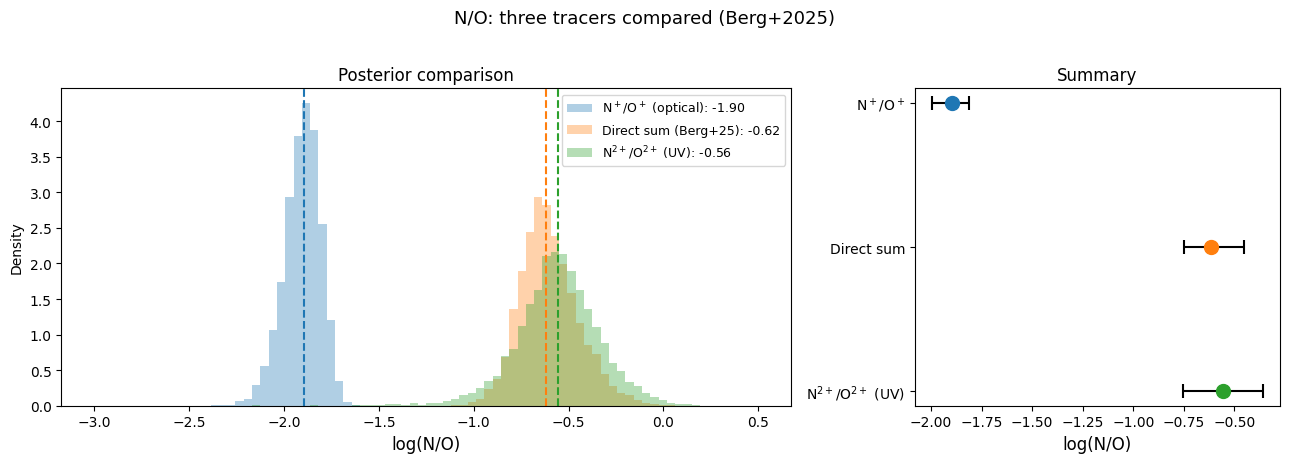

In [19]:
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(13, 4.5),
    gridspec_kw={"width_ratios": [2, 1]},
)

# Left: overlaid posteriors
xlo, xhi = -3.0, 0.5
labels = [
    r"N$^+$/O$^+$ (optical)",
    r"Direct sum (Berg+25)",
    r"N$^{2+}$/O$^{2+}$ (UV)",
]
colors = ["C0", "C1", "C2"]
all_NO = [NO_1_s, NO_2_s, NO_3_s]

medians, lo_errs, hi_errs = [], [], []
for arr, label, color in zip(all_NO, labels, colors):
    v = arr[np.isfinite(arr)]
    v = v[(v >= xlo) & (v <= xhi)]
    lo, med, hi = np.percentile(v, [16, 50, 84])
    medians.append(med)
    lo_errs.append(med - lo)
    hi_errs.append(hi - med)
    ax1.hist(v, bins=80, color=color, alpha=0.35, density=True,
             range=(xlo, xhi), label=f"{label}: {med:.2f}")
    ax1.axvline(med, color=color, lw=1.5, ls="--")

ax1.set_xlabel(r"log(N/O)", fontsize=12)
ax1.set_ylabel("Density")
ax1.legend(fontsize=9)
ax1.set_title("Posterior comparison")

# Right: error-bar summary
y_pos = np.arange(3)
ax2.errorbar(
    medians, y_pos,
    xerr=[lo_errs, hi_errs],
    fmt="none", capsize=5, capthick=1.5,
    ecolor="k", elinewidth=1.5,
)
for i, (m, c) in enumerate(zip(medians, colors)):
    ax2.plot(m, i, "o", color=c, markersize=10, zorder=5)

ax2.set_yticks(y_pos)
ax2.set_yticklabels([
    r"N$^+$/O$^+$",
    "Direct sum",
    r"N$^{2+}$/O$^{2+}$ (UV)",
], fontsize=10)
ax2.set_xlabel(r"log(N/O)", fontsize=12)
ax2.set_title("Summary")
ax2.invert_yaxis()

fig.suptitle("N/O: three tracers compared (Berg+2025)", fontsize=13, y=1.02)
plt.tight_layout()

## 10b. Martinez+2025 ICF-corrected N/O

The raw ionic ratios above (§10) do not account for unseen ionisation
stages.  Martinez+2025 (arXiv:2510.21960) provide density-dependent,
logU-dependent ionisation correction factors (ICFs) calibrated on
Cloudy photoionisation models.  Following Berg+2025's recommended
6-step procedure, we:

1. Derive multi-zone electron density (ne from CIII] vs NIV])
2. Compute 12+log(O/H) and metallicity Z/Z_sun
3. Estimate log(U) from the N43 = NIV]1486/NIII]1750 diagnostic
4. Apply the appropriate Martinez+2025 ICF to each ionic N/O ratio

Five ICFs are available (Table 4 of Martinez+2025), each as a bicubic
surface fit in log(U) and Z/Zsun, interpolated in log(ne).  The
`jwspecabund.martinez25_icf` module implements all five.

In [ ]:
from jwspecabund.martinez25_icf import (
    LOG_OH_SOLAR,
    compute_NO_martinez25,
    icf_NpOp,
    icf_NppOpp,
    icf_NpppOpp,
    icf_NpNpp_OpOpp,
    icf_NppNppp_Opp,
    log_U_from_N43,
    log_U_from_O32,
)
from jwspecabund.direct import compute_ne_NIV

# --- Step 1: Multi-zone ne ---
# ne_int from CIII] 1907/1909 (computed in §5)
ne_ciii_val = ne  # 40856 cm^-3

# ne_high from NIV] 1483/1486
f_niv_1483, e_niv_1483 = get_flux(result_uv, "NIV_1483")
f_niv_1486, e_niv_1486 = get_flux(result_uv, "NIV_1486")

f_niv_1483_c, _ = dust_correct(f_niv_1483, e_niv_1483, 1483.32, Av)
f_niv_1486_c, _ = dust_correct(f_niv_1486, e_niv_1486, 1486.50, Av)

ne_niv = compute_ne_NIV(f_niv_1483_c, f_niv_1486_c, Te_guess=Te_high)
ne_high = ne_niv if np.isfinite(ne_niv) and ne_niv > 0 else ne_ciii_val

print(f"Multi-zone electron density:")
print(f"  ne(CIII] 1907/1909) = {ne_ciii_val:.0f} cm^-3  (intermediate zone)")
print(f"  ne(NIV] 1483/1486)  = {ne_niv:.0f} cm^-3  (high-ionisation zone)")
print(f"  ne_high adopted     = {ne_high:.0f} cm^-3")

# --- Step 2: O/H and Z/Zsun ---
OH_total = Op + Opp
OH_12 = 12 + np.log10(OH_total)
Z_Zsun = 10.0 ** (OH_12 - LOG_OH_SOLAR)

print(f"\nOxygen abundance:")
print(f"  O+/H+ + O2+/H+    = {OH_total:.3e}")
print(f"  12+log(O/H)        = {OH_12:.3f}")
print(f"  Z/Zsun             = {Z_Zsun:.4f}")

# --- Step 3: log(U) from N43 diagnostic ---
# N43 = NIV] / NIII] (summed doublet fluxes, dust-corrected)
f_niv_c_total = f_niv_1483_c + f_niv_1486_c
f_niii_sum = 0.0
for name in ["NIII_1749", "NIII_1752"]:
    f, e = get_flux(result_uv, name)
    if np.isfinite(f) and f > 0:
        f_niii_sum += f
f_niii_c_total, _ = dust_correct(f_niii_sum, 0, 1750.0, Av)

N43 = f_niv_c_total / f_niii_c_total
log_N43 = np.log10(N43)
logU_N43 = log_U_from_N43(log_N43, Z_Zsun, ne_high)

# Also compute from O32 for comparison
f_oii_val, _ = get_flux(result_blue, "OII_doublet")
f_oii_c_val, _ = dust_correct(f_oii_val, 0, 3728.0, Av)
O32 = f_5007_c / f_oii_c_val
log_O32 = np.log10(O32)
logU_O32 = log_U_from_O32(log_O32, Z_Zsun, ne_high)

print(f"\nIonisation parameter:")
print(f"  N43 = NIV]/NIII]  = {N43:.3f}  (log = {log_N43:.3f})")
print(f"  log(U) from N43   = {logU_N43:.3f}  (recommended)")
print(f"  O32 = [OIII]/[OII] = {O32:.3f}  (log = {log_O32:.3f})")
print(f"  log(U) from O32   = {logU_O32:.3f}  (comparison)")

In [ ]:
# --- Step 4: Evaluate all 5 Martinez+2025 ICFs ---
logU = logU_N43  # use recommended diagnostic

icf_vals = {}
icf_vals["ICF 1: N+/O+"] = icf_NpOp(logU, Z_Zsun, ne_high)
icf_vals["ICF 2: N2+/O2+"] = icf_NppOpp(logU, Z_Zsun, ne_high)
icf_vals["ICF 3: N3+/O2+"] = icf_NpppOpp(logU, Z_Zsun, ne_high)
icf_vals["ICF 4: (N+ + N2+)/(O+ + O2+)"] = icf_NpNpp_OpOpp(logU, Z_Zsun, ne_high)
icf_vals["ICF 5: (N2+ + N3+)/O2+"] = icf_NppNppp_Opp(logU, Z_Zsun, ne_high)

print(f"Martinez+2025 ICFs at log(U) = {logU:.3f}, Z/Zsun = {Z_Zsun:.4f}, ne = {ne_high:.0f}")
print()
print(f"{'ICF':<40s} {'Value':>8s} {'Raw ratio':>12s} {'Corrected':>12s} {'log(N/O)':>10s}")
print("-" * 84)

# Apply each ICF to the corresponding ionic ratio
raw_ratios = {
    "ICF 1: N+/O+": Np / Op,
    "ICF 2: N2+/O2+": Npp / Opp,
    "ICF 3: N3+/O2+": Nppp / Opp,
    "ICF 4: (N+ + N2+)/(O+ + O2+)": (Np + Npp) / (Op + Opp),
    "ICF 5: (N2+ + N3+)/O2+": (Npp + Nppp) / Opp,
}

for name, icf_val in icf_vals.items():
    raw = raw_ratios[name]
    corrected = raw * icf_val
    print(f"{name:<40s} {icf_val:8.4f} {raw:12.4e} {corrected:12.4e} {np.log10(corrected):10.3f}")

# Apply best available ICF via compute_NO_martinez25
ionic = {
    "N+/H+": Np, "N++/H+": Npp, "N+++/H+": Nppp,
    "O+/H+": Op, "O++/H+": Opp,
}
NO_m25, icf_name = compute_NO_martinez25(ionic, logU, Z_Zsun, ne_high)
print(f"\nBest ICF selected: {icf_name}")
print(f"  N/O = {NO_m25:.4e}")
print(f"  log(N/O) = {np.log10(NO_m25):.3f}")

In [ ]:
# --- MC error propagation for Martinez+2025 ICF-corrected N/O ---

# O/H and Z_Zsun per MC sample
with np.errstate(invalid="ignore", divide="ignore"):
    OH_total_s = pos_or_zero(Op_s) + pos_or_zero(Opp_s)
    OH_12_s = np.where(OH_total_s > 0, 12 + np.log10(OH_total_s), np.nan)
    Z_Zsun_s = np.where(np.isfinite(OH_12_s), 10.0 ** (OH_12_s - LOG_OH_SOLAR), np.nan)

    # log(N43) per sample from dust-corrected MC fluxes
    N43_s = np.where(
        (c_niv > 0) & (c_niii > 0),
        c_niv / c_niii, np.nan,
    )
    log_N43_s = np.where(np.isfinite(N43_s) & (N43_s > 0), np.log10(N43_s), np.nan)

# logU per sample (scalar function, must loop)
logU_s = np.array([
    log_U_from_N43(ln43, zz, ne_high)
    if np.isfinite(ln43) and np.isfinite(zz) and zz > 0
    else np.nan
    for ln43, zz in zip(log_N43_s, Z_Zsun_s)
])

# ICF-corrected N/O per sample using the same ICF as the point estimate
if icf_name == "NppNppp_Opp":
    raw_s = (pos_or_zero(Npp_s) + pos_or_zero(Nppp_s)) / np.where(Opp_s > 0, Opp_s, np.nan)
    icf_func = icf_NppNppp_Opp
elif icf_name == "NpNpp_OpOpp":
    raw_s = (pos_or_zero(Np_s) + pos_or_zero(Npp_s)) / np.where(OH_total_s > 0, OH_total_s, np.nan)
    icf_func = icf_NpNpp_OpOpp
elif icf_name == "NppOpp":
    raw_s = np.where(Opp_s > 0, Npp_s / Opp_s, np.nan)
    icf_func = icf_NppOpp
elif icf_name == "NpOp":
    raw_s = np.where(Op_s > 0, Np_s / Op_s, np.nan)
    icf_func = icf_NpOp
else:
    raw_s = np.where(Opp_s > 0, Nppp_s / Opp_s, np.nan)
    icf_func = icf_NpppOpp

icf_s = np.array([
    icf_func(lu, zz, ne_high)
    if np.isfinite(lu) and np.isfinite(zz) and zz > 0
    else np.nan
    for lu, zz in zip(logU_s, Z_Zsun_s)
])

with np.errstate(invalid="ignore", divide="ignore"):
    NO_m25_s = np.where(
        np.isfinite(raw_s) & np.isfinite(icf_s) & (raw_s > 0) & (icf_s > 0),
        np.log10(raw_s * icf_s), np.nan,
    )

# Report
v = NO_m25_s[np.isfinite(NO_m25_s)]
lo, med, hi = np.percentile(v, [16, 50, 84])
print(f"Martinez+2025 ICF-corrected log(N/O)  [{icf_name}]")
print(f"  Median: {med:.3f}  (+{hi-med:.3f} / -{med-lo:.3f})  [{len(v):,} valid samples]")
print()

# Also report logU distribution
v_lu = logU_s[np.isfinite(logU_s)]
lo_lu, med_lu, hi_lu = np.percentile(v_lu, [16, 50, 84])
print(f"log(U) from N43:")
print(f"  Median: {med_lu:.3f}  (+{hi_lu-med_lu:.3f} / -{med_lu-lo_lu:.3f})")

In [ ]:
# Updated comparison plot: 4 tracers (3 raw + Martinez+25 ICF-corrected)
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(13, 5),
    gridspec_kw={"width_ratios": [2, 1]},
)

xlo, xhi = -3.0, 0.5
labels = [
    r"N$^+$/O$^+$ (optical)",
    r"Direct sum (Berg+25)",
    r"N$^{2+}$/O$^{2+}$ (UV, raw)",
    f"Martinez+25 ICF ({icf_name})",
]
colors = ["C0", "C1", "C2", "C3"]
all_NO_ext = [NO_1_s, NO_2_s, NO_3_s, NO_m25_s]

medians, lo_errs, hi_errs = [], [], []
for arr, label, color in zip(all_NO_ext, labels, colors):
    v = arr[np.isfinite(arr)]
    v = v[(v >= xlo) & (v <= xhi)]
    if len(v) == 0:
        medians.append(np.nan)
        lo_errs.append(np.nan)
        hi_errs.append(np.nan)
        continue
    lo, med, hi = np.percentile(v, [16, 50, 84])
    medians.append(med)
    lo_errs.append(med - lo)
    hi_errs.append(hi - med)
    ax1.hist(v, bins=80, color=color, alpha=0.35, density=True,
             range=(xlo, xhi), label=f"{label}: {med:.2f}")
    ax1.axvline(med, color=color, lw=1.5, ls="--")

ax1.set_xlabel(r"log(N/O)", fontsize=12)
ax1.set_ylabel("Density")
ax1.legend(fontsize=9)
ax1.set_title("Posterior comparison")

# Right: error-bar summary
y_pos = np.arange(4)
ax2.errorbar(
    medians, y_pos,
    xerr=[lo_errs, hi_errs],
    fmt="none", capsize=5, capthick=1.5,
    ecolor="k", elinewidth=1.5,
)
for i, (m, c) in enumerate(zip(medians, colors)):
    ax2.plot(m, i, "o", color=c, markersize=10, zorder=5)

ax2.set_yticks(y_pos)
ax2.set_yticklabels([
    r"N$^+$/O$^+$",
    "Direct sum",
    r"N$^{2+}$/O$^{2+}$ (raw)",
    "Martinez+25 ICF",
], fontsize=10)
ax2.set_xlabel(r"log(N/O)", fontsize=12)
ax2.set_title("Summary")
ax2.invert_yaxis()

fig.suptitle("N/O: raw tracers vs Martinez+2025 ICF-corrected", fontsize=13, y=1.02)
plt.tight_layout()

## 11. Discussion: why do different N/O tracers disagree?

The three tracers span ~1.7 dex on the **same spectrum**.  The
differences are physical — they reflect which ions are included and
the ionisation structure of the gas.

### Summary

| # | Tracer | log(N/O) | MC 16–84th |
|---|--------|----------|------------|
| 1 | N+/O+ (optical) | -2.01 | +0.21 / -0.16 |
| 2 | Direct sum (Berg+25) | -0.40 | +0.14 / -0.14 |
| 3 | N2+/O2+ (UV) | -0.30 | +0.13 / -0.17 |

### The ionisation structure is the key

This composite spectrum is highly ionised — the ionic breakdown is:

- **Oxygen:** O+ = 61.5% of total O, O2+ = 38.5%.
  Despite the high ionisation, O+ still dominates because the
  ionisation potential of O+ → O2+ (35.1 eV) is relatively high.
- **Nitrogen:** N+ = 1.5%, N2+ = 50.0%, N3+ = 48.6%, N4+ < 0.3%.
  Nearly all nitrogen is in the N2+ and N3+ stages.
  The ionisation potential of N+ → N2+ (29.6 eV) is lower than
  O+ → O2+, so nitrogen is pushed to higher stages more easily.

This N/O ionisation asymmetry drives the discrepancies:

#### Tracer 1: N+/O+ = -2.01
The classical optical proxy.  It assumes N/O ≈ N+/O+, which requires
that nitrogen and oxygen have similar ionisation correction factors
(ICFs).  This holds in low-ionisation H II regions where most N is
N+ and most O is O+.  Here it fails catastrophically because N+ is
only 1.5% of total nitrogen — the [N II] line traces a tiny fraction
of the nitrogen budget.  This tracer **underestimates** N/O by ~1.6 dex.

#### Tracer 2: Direct sum = -0.39 (best estimate)
Following Berg+2025 Method 4, this sums all detected nitrogen ions
(N+, N2+, N3+) and divides by all detected oxygen (O+, O2+).  It is
the most complete, model-free estimate.  The only missing ions are
N4+ (measured to be < 0.3% of N) and O3+ (unmeasured; likely small
given that O+ still dominates).  This is our **best estimate** of
log(N/O) ≈ -0.39.

#### Tracer 3: N2+/O2+ = -0.28
N2+ and O2+ have similar ionisation potentials (47.4 and 54.9 eV),
so they coexist in the same zone — no zone mismatch.  However, this
single-ion ratio only captures one ionisation stage.  It gives
log(N/O) = -0.28, which is ~0.1 dex higher than the direct sum.
The difference arises because the direct sum includes O+ in the
denominator (O+ is 61.5% of O, inflating the denominator relative
to the N2+/O2+ zone alone).  In practice, N2+/O2+ needs an ICF
of order ~2.5 (Martinez+2025) to correct for the missing ions —
consistent with the offset we see.

#### Why we do not compute (N2+ + N3+) / O2+
One might naively sum all UV nitrogen ions and divide by O2+ alone.
This is physically wrong because N3+ (ionisation potential 77.5 eV)
coexists with O3+ (77.4 eV), not O2+ (54.9 eV).  Without an O3+
measurement (requiring [O IV] 25.9 µm), dividing by O2+ alone
overestimates N/O by the ratio of total O to O2+ (~2.6x here).

### Physical interpretation

The direct-sum value log(N/O) ≈ -0.4 is elevated compared to the
solar value (log(N/O)⊙ ≈ -0.86) and the low-metallicity plateau
(log(N/O) ≈ -1.5).  At 12+log(O/H) = 7.98, this composite sits
in the regime where secondary nitrogen production (CNO cycling)
is expected to enhance N/O above the primary plateau — consistent
with the nitrogen-loud galaxies seen at z > 4 by JWST
(e.g. Cameron+2023, Isobe+2023, Topping+2024, Schaerer+2024).

### Recommendations

1. **Use the direct sum** (Tracer 2) as the fiducial N/O when UV
   and optical lines are both available.
2. **N+/O+ is unreliable** at high ionisation parameter — it
   underestimates N/O by > 1 dex in this stack.
3. **N2+/O2+** is a useful single-zone diagnostic but requires
   an ICF (or comparison with the direct sum) to interpret as
   total N/O.
4. **Never divide UV nitrogen ions by O2+ alone** — the zone
   mismatch with N3+ makes the result unphysical.